In [2]:
# ============================================================================
# ЛАБОРАТОРНАЯ РАБОТА №5.2: ОБУЧЕНИЕ НА ОСНОВЕ ВРЕМЕННЫХ РАЗЛИЧИЙ
# LABORATORY WORK #5.2: TEMPORAL DIFFERENCE LEARNING
# ============================================================================
# Реализация алгоритмов:
# 1. SARSA
# 2. Q-learning
# 3. Double Q-learning
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

try:
    import gymnasium as gym
    print("Используется gymnasium / Using gymnasium")
except ImportError:
    import gym
    print("Используется gym / Using gym")

%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ")
print("All libraries loaded successfully")
print("=" * 60)

# ============================================================================
# ЗАГРУЗКА СРЕДЫ TAXI-V4
# LOAD TAXI-V4 ENVIRONMENT
# ============================================================================

env = gym.make('Taxi-v4')

n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"\nИНФОРМАЦИЯ О СРЕДЕ TAXI-V4 / ENVIRONMENT INFO:")
print(f"  Количество состояний / Number of states: {n_states}")
print(f"  Количество действий / Number of actions: {n_actions}")
print(f"  Действия / Actions:")
print(f"    0 = Юг (DOWN / South)")
print(f"    1 = Север (UP / North)")
print(f"    2 = Восток (RIGHT / East)")
print(f"    3 = Запад (LEFT / West)")
print(f"    4 = Взять пассажира (PICKUP)")
print(f"    5 = Высадить пассажира (DROPOFF)")

print("\n" + "=" * 60)
print("СРЕДА ЗАГРУЖЕНА / ENVIRONMENT LOADED")
print("=" * 60)

Используется gymnasium / Using gymnasium
БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ
All libraries loaded successfully

ИНФОРМАЦИЯ О СРЕДЕ TAXI-V4 / ENVIRONMENT INFO:
  Количество состояний / Number of states: 500
  Количество действий / Number of actions: 6
  Действия / Actions:
    0 = Юг (DOWN / South)
    1 = Север (UP / North)
    2 = Восток (RIGHT / East)
    3 = Запад (LEFT / West)
    4 = Взять пассажира (PICKUP)
    5 = Высадить пассажира (DROPOFF)

СРЕДА ЗАГРУЖЕНА / ENVIRONMENT LOADED


In [3]:
# ============================================================================
# EPSILON-GREEDY ПОЛИТИКА
# EPSILON-GREEDY POLICY
# ============================================================================

print("=" * 60)
print("EPSILON-GREEDY ПОЛИТИКА")
print("EPSILON-GREEDY POLICY")
print("=" * 60)

def epsilon_greedy(Q, state, epsilon):
    """
    Epsilon-greedy политика выбора действия
    Epsilon-greedy policy for action selection
    
    Параметры / Parameters:
        Q - Q-таблица / Q-table
        state - текущее состояние / current state
        epsilon - вероятность случайного действия / exploration rate
    
    Возвращает / Returns:
        action - выбранное действие / selected action
    """
    if np.random.random() < epsilon:
        # Исследование: случайное действие / Exploration: random action
        action = np.random.randint(Q.shape[1])
    else:
        # Использование: лучшее действие по Q-таблице / Exploitation: best action from Q-table
        action = np.argmax(Q[state])
    
    return action


# Демонстрация работы функции
print("\nДемонстрация работы epsilon-greedy / Demonstration:")

# Создаем маленькую Q-таблицу для примера
test_Q = np.zeros((500, 6))
test_state = 0

print(f"  Состояние / State: {test_state}")
print(f"  Q-значения / Q-values: {test_Q[test_state]}")

for eps in [0.0, 0.5, 1.0]:
    actions = []
    for _ in range(10):
        actions.append(epsilon_greedy(test_Q, test_state, eps))
    print(f"  epsilon={eps}: выбранные действия / selected actions = {actions}")

print("\n✓ Функция epsilon-greedy готова / Function ready")

EPSILON-GREEDY ПОЛИТИКА
EPSILON-GREEDY POLICY

Демонстрация работы epsilon-greedy / Demonstration:
  Состояние / State: 0
  Q-значения / Q-values: [0. 0. 0. 0. 0. 0.]
  epsilon=0.0: выбранные действия / selected actions = [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  epsilon=0.5: выбранные действия / selected actions = [np.int64(0), np.int64(0), 2, 4, np.int64(0), 4, np.int64(0), 3, np.int64(0), np.int64(0)]
  epsilon=1.0: выбранные действия / selected actions = [3, 5, 2, 3, 0, 0, 1, 4, 4, 0]

✓ Функция epsilon-greedy готова / Function ready


In [4]:
# ============================================================================
# АЛГОРИТМ SARSA (State-Action-Reward-State-Action)
# ============================================================================

print("=" * 60)
print("АЛГОРИТМ SARSA")
print("=" * 60)

def sarsa(env, episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1, 
          epsilon_decay=0.995, min_epsilon=0.01):
    """
    SARSA алгоритм для обучения с подкреплением
    SARSA algorithm for reinforcement learning
    
    Параметры / Parameters:
        env - среда / environment
        episodes - количество эпизодов / number of episodes
        alpha - скорость обучения / learning rate
        gamma - коэффициент дисконтирования / discount factor
        epsilon - начальная вероятность случайного действия / initial exploration rate
        epsilon_decay - затухание epsilon / epsilon decay
        min_epsilon - минимальное значение epsilon / minimum epsilon
    
    Возвращает / Returns:
        Q - таблица Q-значений / Q-table
        rewards_history - история наград / reward history
        steps_history - история шагов / step history
        eps_history - история epsilon / epsilon history
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    # Инициализация Q-таблицы нулями
    Q = np.zeros((n_states, n_actions))
    rewards_history = []
    steps_history = []
    eps_history = []
    
    for episode in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        total_reward = 0
        steps = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            
            # Выбор следующего действия по epsilon-greedy
            next_action = epsilon_greedy(Q, next_state, epsilon)
            
            # Обновление Q-значения по формуле SARSA
            # Q(s,a) = Q(s,a) + α * [r + γ * Q(s',a') - Q(s,a)]
            Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])
            
            state = next_state
            action = next_action
            
            if terminated or truncated:
                break
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        eps_history.append(epsilon)
        
        # Затухание epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        
        # Вывод прогресса каждые 200 эпизодов
        if (episode + 1) % 200 == 0:
            avg_reward = np.mean(rewards_history[-200:])
            print(f"  Эпизод {episode + 1}: средняя награда = {avg_reward:.2f}, epsilon = {epsilon:.3f}")
    
    return Q, rewards_history, steps_history, eps_history


# Запуск SARSA
print("\nЗапуск SARSA...")
print("Запуск может занять 10-20 секунд / Training may take 10-20 seconds")
print("-" * 40)

start_time = time.time()
Q_sarsa, rewards_sarsa, steps_sarsa, eps_sarsa = sarsa(
    env, episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1, 
    epsilon_decay=0.995, min_epsilon=0.01
)
end_time = time.time()

print(f"\nВремя выполнения / Time: {end_time - start_time:.2f} сек")
print(f"Финальная награда / Final reward (последние 100 эпизодов): {np.mean(rewards_sarsa[-100:]):.2f}")

print("\n✅ SARSA обучение завершено / SARSA training completed")

АЛГОРИТМ SARSA

Запуск SARSA...
Запуск может занять 10-20 секунд / Training may take 10-20 seconds
----------------------------------------
  Эпизод 200: средняя награда = -278.99, epsilon = 0.037
  Эпизод 400: средняя награда = -142.06, epsilon = 0.013
  Эпизод 600: средняя награда = -78.64, epsilon = 0.010
  Эпизод 800: средняя награда = -29.41, epsilon = 0.010
  Эпизод 1000: средняя награда = -13.09, epsilon = 0.010
  Эпизод 1200: средняя награда = -3.87, epsilon = 0.010
  Эпизод 1400: средняя награда = 1.18, epsilon = 0.010
  Эпизод 1600: средняя награда = 5.48, epsilon = 0.010
  Эпизод 1800: средняя награда = 5.05, epsilon = 0.010
  Эпизод 2000: средняя награда = 6.46, epsilon = 0.010

Время выполнения / Time: 2.78 сек
Финальная награда / Final reward (последние 100 эпизодов): 7.30

✅ SARSA обучение завершено / SARSA training completed


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ SARSA
VISUALIZATION OF SARSA RESULTS


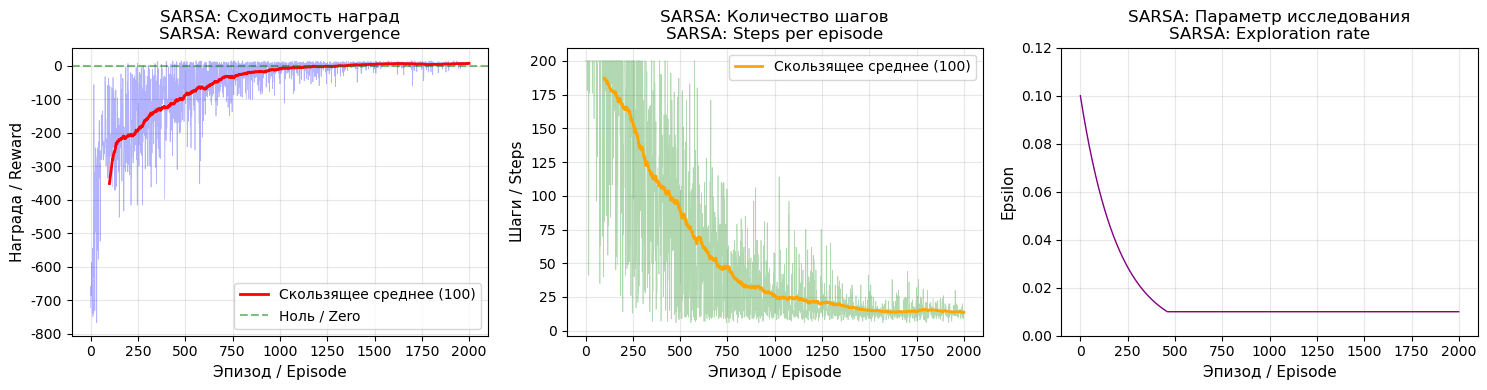


----------------------------------------
СТАТИСТИКА SARSA / SARSA STATISTICS
----------------------------------------
  Лучшая награда / Best reward: 15
  Средняя награда (последние 100 эпизодов) / Mean reward (last 100 episodes): 7.30
  Среднее количество шагов (последние 100) / Mean steps (last 100): 13.61
  Минимальное количество шагов / Min steps: 6

✅ SARSA визуализация завершена / SARSA visualization completed


In [5]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ SARSA
# VISUALIZATION OF SARSA RESULTS
# ============================================================================

print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ SARSA")
print("VISUALIZATION OF SARSA RESULTS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Награды
window = 100
smoothed_rewards = np.convolve(rewards_sarsa, np.ones(window)/window, mode='valid')

axes[0].plot(rewards_sarsa, alpha=0.3, linewidth=0.5, color='blue')
axes[0].plot(range(window-1, len(rewards_sarsa)), smoothed_rewards, 'r-', linewidth=2, label='Скользящее среднее (100)')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Ноль / Zero')
axes[0].set_xlabel('Эпизод / Episode', fontsize=11)
axes[0].set_ylabel('Награда / Reward', fontsize=11)
axes[0].set_title('SARSA: Сходимость наград\nSARSA: Reward convergence', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Шаги
smoothed_steps = np.convolve(steps_sarsa, np.ones(window)/window, mode='valid')

axes[1].plot(steps_sarsa, alpha=0.3, linewidth=0.5, color='green')
axes[1].plot(range(window-1, len(steps_sarsa)), smoothed_steps, 'orange', linewidth=2, label='Скользящее среднее (100)')
axes[1].set_xlabel('Эпизод / Episode', fontsize=11)
axes[1].set_ylabel('Шаги / Steps', fontsize=11)
axes[1].set_title('SARSA: Количество шагов\nSARSA: Steps per episode', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Epsilon
axes[2].plot(eps_sarsa, 'purple', linewidth=1)
axes[2].set_xlabel('Эпизод / Episode', fontsize=11)
axes[2].set_ylabel('Epsilon', fontsize=11)
axes[2].set_title('SARSA: Параметр исследования\nSARSA: Exploration rate', fontsize=12)
axes[2].set_ylim(0, 0.12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("\n" + "-" * 40)
print("СТАТИСТИКА SARSA / SARSA STATISTICS")
print("-" * 40)
print(f"  Лучшая награда / Best reward: {np.max(rewards_sarsa)}")
print(f"  Средняя награда (последние 100 эпизодов) / Mean reward (last 100 episodes): {np.mean(rewards_sarsa[-100:]):.2f}")
print(f"  Среднее количество шагов (последние 100) / Mean steps (last 100): {np.mean(steps_sarsa[-100:]):.2f}")
print(f"  Минимальное количество шагов / Min steps: {np.min(steps_sarsa)}")

print("\n✅ SARSA визуализация завершена / SARSA visualization completed")

In [6]:
# ============================================================================
# АЛГОРИТМ Q-LEARNING
# ============================================================================

print("=" * 60)
print("АЛГОРИТМ Q-LEARNING")
print("=" * 60)

def q_learning(env, episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1, 
               epsilon_decay=0.995, min_epsilon=0.01):
    """
    Q-learning алгоритм для обучения с подкреплением
    Q-learning algorithm for reinforcement learning
    
    Отличие от SARSA: используется максимальное Q-значение следующего состояния
    Difference from SARSA: uses max Q-value of next state
    
    Формула обновления / Update formula:
    Q(s,a) = Q(s,a) + α * [r + γ * max_a' Q(s',a') - Q(s,a)]
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    # Инициализация Q-таблицы нулями
    Q = np.zeros((n_states, n_actions))
    rewards_history = []
    steps_history = []
    eps_history = []
    
    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0
        epsilon_current = epsilon
        
        while True:
            # Выбор действия по epsilon-greedy
            action = epsilon_greedy(Q, state, epsilon_current)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            
            # Обновление Q-значения по формуле Q-learning (используем max)
            best_next_value = np.max(Q[next_state])
            Q[state, action] += alpha * (reward + gamma * best_next_value - Q[state, action])
            
            state = next_state
            
            if terminated or truncated:
                break
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        eps_history.append(epsilon_current)
        
        # Затухание epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        
        # Вывод прогресса каждые 200 эпизодов
        if (episode + 1) % 200 == 0:
            avg_reward = np.mean(rewards_history[-200:])
            print(f"  Эпизод {episode + 1}: средняя награда = {avg_reward:.2f}, epsilon = {epsilon:.3f}")
    
    return Q, rewards_history, steps_history, eps_history


# Запуск Q-learning
print("\nЗапуск Q-learning...")
print("Запуск может занять 10-20 секунд / Training may take 10-20 seconds")
print("-" * 40)

start_time = time.time()
Q_qlearning, rewards_qlearning, steps_qlearning, eps_qlearning = q_learning(
    env, episodes=2000, alpha=0.1, gamma=0.9, epsilon=0.1, 
    epsilon_decay=0.995, min_epsilon=0.01
)
end_time = time.time()

print(f"\nВремя выполнения / Time: {end_time - start_time:.2f} сек")
print(f"Финальная награда (последние 100 эпизодов) / Final reward (last 100 episodes): {np.mean(rewards_qlearning[-100:]):.2f}")

print("\n✅ Q-learning обучение завершено / Q-learning training completed")

АЛГОРИТМ Q-LEARNING

Запуск Q-learning...
Запуск может занять 10-20 секунд / Training may take 10-20 seconds
----------------------------------------
  Эпизод 200: средняя награда = -252.88, epsilon = 0.037
  Эпизод 400: средняя награда = -136.48, epsilon = 0.013
  Эпизод 600: средняя награда = -72.56, epsilon = 0.010
  Эпизод 800: средняя награда = -27.29, epsilon = 0.010
  Эпизод 1000: средняя награда = -10.54, epsilon = 0.010
  Эпизод 1200: средняя награда = -2.58, epsilon = 0.010
  Эпизод 1400: средняя награда = 1.91, epsilon = 0.010
  Эпизод 1600: средняя награда = 4.09, epsilon = 0.010
  Эпизод 1800: средняя награда = 6.26, epsilon = 0.010
  Эпизод 2000: средняя награда = 6.79, epsilon = 0.010

Время выполнения / Time: 3.54 сек
Финальная награда (последние 100 эпизодов) / Final reward (last 100 episodes): 6.65

✅ Q-learning обучение завершено / Q-learning training completed


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ Q-LEARNING
VISUALIZATION OF Q-LEARNING RESULTS


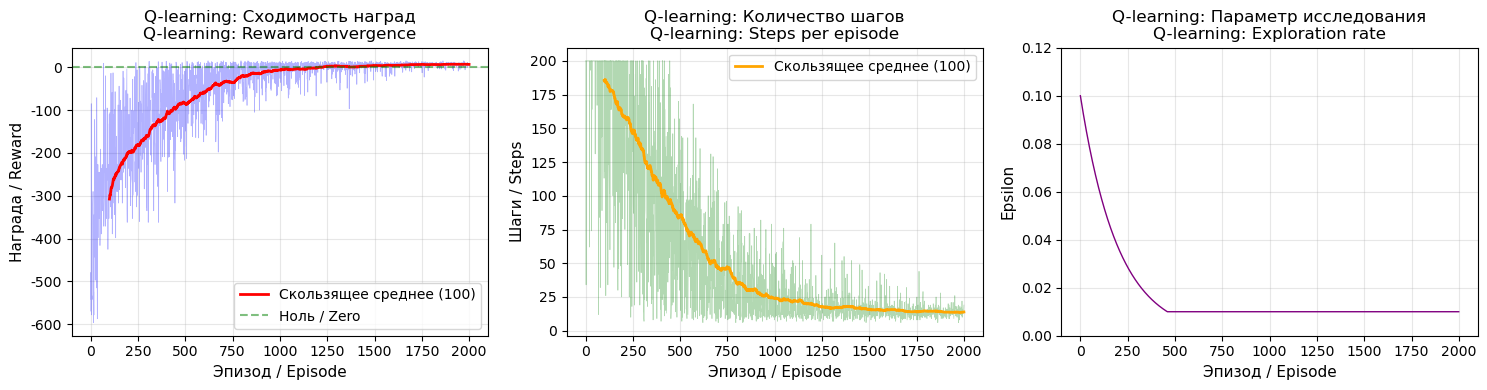


----------------------------------------
СТАТИСТИКА Q-LEARNING / Q-LEARNING STATISTICS
----------------------------------------
  Лучшая награда / Best reward: 15
  Средняя награда (последние 100) / Mean reward (last 100): 6.65
  Среднее количество шагов (последние 100) / Mean steps (last 100): 13.90
  Минимальное количество шагов / Min steps: 6

✅ Q-learning визуализация завершена / Q-learning visualization completed


In [7]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ Q-LEARNING
# VISUALIZATION OF Q-LEARNING RESULTS
# ============================================================================

print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ Q-LEARNING")
print("VISUALIZATION OF Q-LEARNING RESULTS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Награды
window = 100
smoothed_rewards_q = np.convolve(rewards_qlearning, np.ones(window)/window, mode='valid')

axes[0].plot(rewards_qlearning, alpha=0.3, linewidth=0.5, color='blue')
axes[0].plot(range(window-1, len(rewards_qlearning)), smoothed_rewards_q, 'r-', linewidth=2, label='Скользящее среднее (100)')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Ноль / Zero')
axes[0].set_xlabel('Эпизод / Episode', fontsize=11)
axes[0].set_ylabel('Награда / Reward', fontsize=11)
axes[0].set_title('Q-learning: Сходимость наград\nQ-learning: Reward convergence', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Шаги
smoothed_steps_q = np.convolve(steps_qlearning, np.ones(window)/window, mode='valid')

axes[1].plot(steps_qlearning, alpha=0.3, linewidth=0.5, color='green')
axes[1].plot(range(window-1, len(steps_qlearning)), smoothed_steps_q, 'orange', linewidth=2, label='Скользящее среднее (100)')
axes[1].set_xlabel('Эпизод / Episode', fontsize=11)
axes[1].set_ylabel('Шаги / Steps', fontsize=11)
axes[1].set_title('Q-learning: Количество шагов\nQ-learning: Steps per episode', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Epsilon
axes[2].plot(eps_qlearning, 'purple', linewidth=1)
axes[2].set_xlabel('Эпизод / Episode', fontsize=11)
axes[2].set_ylabel('Epsilon', fontsize=11)
axes[2].set_title('Q-learning: Параметр исследования\nQ-learning: Exploration rate', fontsize=12)
axes[2].set_ylim(0, 0.12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 40)
print("СТАТИСТИКА Q-LEARNING / Q-LEARNING STATISTICS")
print("-" * 40)
print(f"  Лучшая награда / Best reward: {np.max(rewards_qlearning)}")
print(f"  Средняя награда (последние 100) / Mean reward (last 100): {np.mean(rewards_qlearning[-100:]):.2f}")
print(f"  Среднее количество шагов (последние 100) / Mean steps (last 100): {np.mean(steps_qlearning[-100:]):.2f}")
print(f"  Минимальное количество шагов / Min steps: {np.min(steps_qlearning)}")

print("\n✅ Q-learning визуализация завершена / Q-learning visualization completed")

In [9]:
# ============================================================================
# АЛГОРИТМ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННАЯ ВЕРСИЯ)
# DOUBLE Q-LEARNING ALGORITHM (OPTIMIZED VERSION)
# ============================================================================

print("=" * 60)
print("АЛГОРИТМ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННЫЙ)")
print("DOUBLE Q-LEARNING ALGORITHM (OPTIMIZED)")
print("=" * 60)

def double_q_learning_optimized(env, episodes=3000, alpha=0.3, gamma=0.95, epsilon=0.3, 
                                epsilon_decay=0.998, min_epsilon=0.05):
    """
    Double Q-learning алгоритм с оптимизированными параметрами
    Double Q-learning algorithm with optimized parameters
    
    Параметры / Parameters:
        env - среда / environment
        episodes - количество эпизодов / number of episodes
        alpha - скорость обучения (увеличена) / learning rate (increased)
        gamma - коэффициент дисконтирования (увеличен) / discount factor (increased)
        epsilon - начальная вероятность случайного действия / initial exploration rate
        epsilon_decay - затухание epsilon (уменьшено для более долгого исследования)
        min_epsilon - минимальное значение epsilon
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    # Две Q-таблицы / Two Q-tables
    Q1 = np.zeros((n_states, n_actions))
    Q2 = np.zeros((n_states, n_actions))
    
    rewards_history = []
    steps_history = []
    eps_history = []
    
    def epsilon_greedy_double(state, eps):
        """Epsilon-greedy с использованием суммы Q1+Q2"""
        if np.random.random() < eps:
            return np.random.randint(n_actions)
        else:
            # Используем сумму для выбора действия
            return np.argmax(Q1[state] + Q2[state])
    
    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0
        eps_current = epsilon * (epsilon_decay ** episode)
        eps_current = max(min_epsilon, eps_current)
        
        while True:
            # Выбор действия
            action = epsilon_greedy_double(state, eps_current)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            
            # Офф-полиси обновление (как в оригинальном Double DQN)
            # Для улучшения стабильности, обновляем обе таблицы
            
            # Обновляем Q1 с использованием Q2 для оценки следующего действия
            best_action_in_Q1 = np.argmax(Q1[next_state])
            td_target1 = reward + gamma * Q2[next_state, best_action_in_Q1]
            Q1[state, action] += alpha * (td_target1 - Q1[state, action])
            
            # Обновляем Q2 с использованием Q1 для оценки следующего действия
            best_action_in_Q2 = np.argmax(Q2[next_state])
            td_target2 = reward + gamma * Q1[next_state, best_action_in_Q2]
            Q2[state, action] += alpha * (td_target2 - Q2[state, action])
            
            state = next_state
            
            if terminated or truncated:
                break
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        eps_history.append(eps_current)
        
        # Вывод прогресса каждые 200 эпизодов
        if (episode + 1) % 200 == 0:
            avg_reward = np.mean(rewards_history[-200:])
            print(f"  Эпизод {episode + 1}: средняя награда = {avg_reward:.2f}, epsilon = {eps_current:.3f}, alpha = {alpha:.2f}")
    
    # Возвращаем среднюю Q-таблицу
    Q_avg = (Q1 + Q2) / 2
    return Q_avg, rewards_history, steps_history, eps_history


# Запуск Double Q-learning
print("\nЗапуск Double Q-learning (оптимизированная версия)...")
print("Запуск может занять 15-25 секунд / Training may take 15-25 seconds")
print("-" * 40)

start_time = time.time()
Q_double_opt, rewards_double_opt, steps_double_opt, eps_double_opt = double_q_learning_optimized(
    env, episodes=3000, alpha=0.3, gamma=0.95, epsilon=0.3, 
    epsilon_decay=0.998, min_epsilon=0.05
)
end_time = time.time()

print(f"\nВремя выполнения / Time: {end_time - start_time:.2f} сек")
print(f"Финальная награда (последние 100 эпизодов) / Final reward (last 100 episodes): {np.mean(rewards_double_opt[-100:]):.2f}")

print("\n✅ Double Q-learning (оптимизированный) обучение завершено")
print("✅ Double Q-learning (optimized) training completed")

АЛГОРИТМ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННЫЙ)
DOUBLE Q-LEARNING ALGORITHM (OPTIMIZED)

Запуск Double Q-learning (оптимизированная версия)...
Запуск может занять 15-25 секунд / Training may take 15-25 seconds
----------------------------------------
  Эпизод 200: средняя награда = -259.59, epsilon = 0.201, alpha = 0.30
  Эпизод 400: средняя награда = -45.67, epsilon = 0.135, alpha = 0.30
  Эпизод 600: средняя награда = -3.06, epsilon = 0.090, alpha = 0.30
  Эпизод 800: средняя награда = 1.88, epsilon = 0.061, alpha = 0.30
  Эпизод 1000: средняя награда = 4.91, epsilon = 0.050, alpha = 0.30
  Эпизод 1200: средняя награда = 5.23, epsilon = 0.050, alpha = 0.30
  Эпизод 1400: средняя награда = 5.22, epsilon = 0.050, alpha = 0.30
  Эпизод 1600: средняя награда = 5.17, epsilon = 0.050, alpha = 0.30
  Эпизод 1800: средняя награда = 4.86, epsilon = 0.050, alpha = 0.30
  Эпизод 2000: средняя награда = 5.55, epsilon = 0.050, alpha = 0.30
  Эпизод 2200: средняя награда = 4.78, epsilon = 0.050, alp

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННЫЙ)
VISUALIZATION OF DOUBLE Q-LEARNING RESULTS (OPTIMIZED)


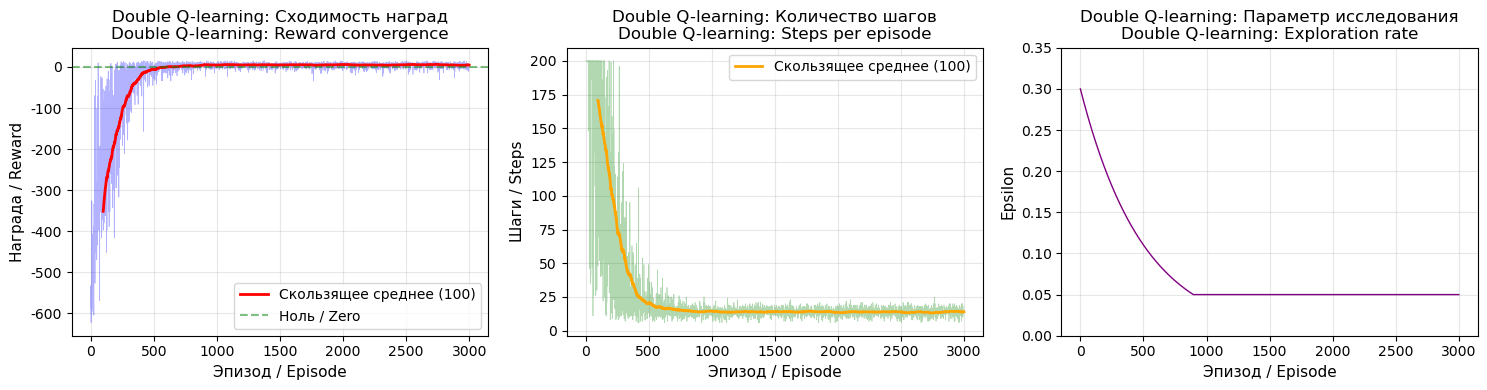


----------------------------------------
СТАТИСТИКА DOUBLE Q-LEARNING / DOUBLE Q-LEARNING STATISTICS
----------------------------------------
  Лучшая награда / Best reward: 15
  Средняя награда (последние 100) / Mean reward (last 100): 4.70
  Среднее количество шагов (последние 100) / Mean steps (last 100): 14.05
  Минимальное количество шагов / Min steps: 6

✅ Double Q-learning визуализация завершена / Double Q-learning visualization completed


In [10]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННЫЙ)
# VISUALIZATION OF DOUBLE Q-LEARNING RESULTS (OPTIMIZED)
# ============================================================================

print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ DOUBLE Q-LEARNING (ОПТИМИЗИРОВАННЫЙ)")
print("VISUALIZATION OF DOUBLE Q-LEARNING RESULTS (OPTIMIZED)")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Награды
window = 100
smoothed_rewards_d = np.convolve(rewards_double_opt, np.ones(window)/window, mode='valid')

axes[0].plot(rewards_double_opt, alpha=0.3, linewidth=0.5, color='blue')
axes[0].plot(range(window-1, len(rewards_double_opt)), smoothed_rewards_d, 'r-', linewidth=2, label='Скользящее среднее (100)')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Ноль / Zero')
axes[0].set_xlabel('Эпизод / Episode', fontsize=11)
axes[0].set_ylabel('Награда / Reward', fontsize=11)
axes[0].set_title('Double Q-learning: Сходимость наград\nDouble Q-learning: Reward convergence', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Шаги
smoothed_steps_d = np.convolve(steps_double_opt, np.ones(window)/window, mode='valid')

axes[1].plot(steps_double_opt, alpha=0.3, linewidth=0.5, color='green')
axes[1].plot(range(window-1, len(steps_double_opt)), smoothed_steps_d, 'orange', linewidth=2, label='Скользящее среднее (100)')
axes[1].set_xlabel('Эпизод / Episode', fontsize=11)
axes[1].set_ylabel('Шаги / Steps', fontsize=11)
axes[1].set_title('Double Q-learning: Количество шагов\nDouble Q-learning: Steps per episode', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Epsilon
axes[2].plot(eps_double_opt, 'purple', linewidth=1)
axes[2].set_xlabel('Эпизод / Episode', fontsize=11)
axes[2].set_ylabel('Epsilon', fontsize=11)
axes[2].set_title('Double Q-learning: Параметр исследования\nDouble Q-learning: Exploration rate', fontsize=12)
axes[2].set_ylim(0, 0.35)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-" * 40)
print("СТАТИСТИКА DOUBLE Q-LEARNING / DOUBLE Q-LEARNING STATISTICS")
print("-" * 40)
print(f"  Лучшая награда / Best reward: {np.max(rewards_double_opt)}")
print(f"  Средняя награда (последние 100) / Mean reward (last 100): {np.mean(rewards_double_opt[-100:]):.2f}")
print(f"  Среднее количество шагов (последние 100) / Mean steps (last 100): {np.mean(steps_double_opt[-100:]):.2f}")
print(f"  Минимальное количество шагов / Min steps: {np.min(steps_double_opt)}")

print("\n✅ Double Q-learning визуализация завершена / Double Q-learning visualization completed")

СРАВНЕНИЕ АЛГОРИТМОВ / ALGORITHMS COMPARISON
SARSA vs Q-LEARNING vs DOUBLE Q-LEARNING


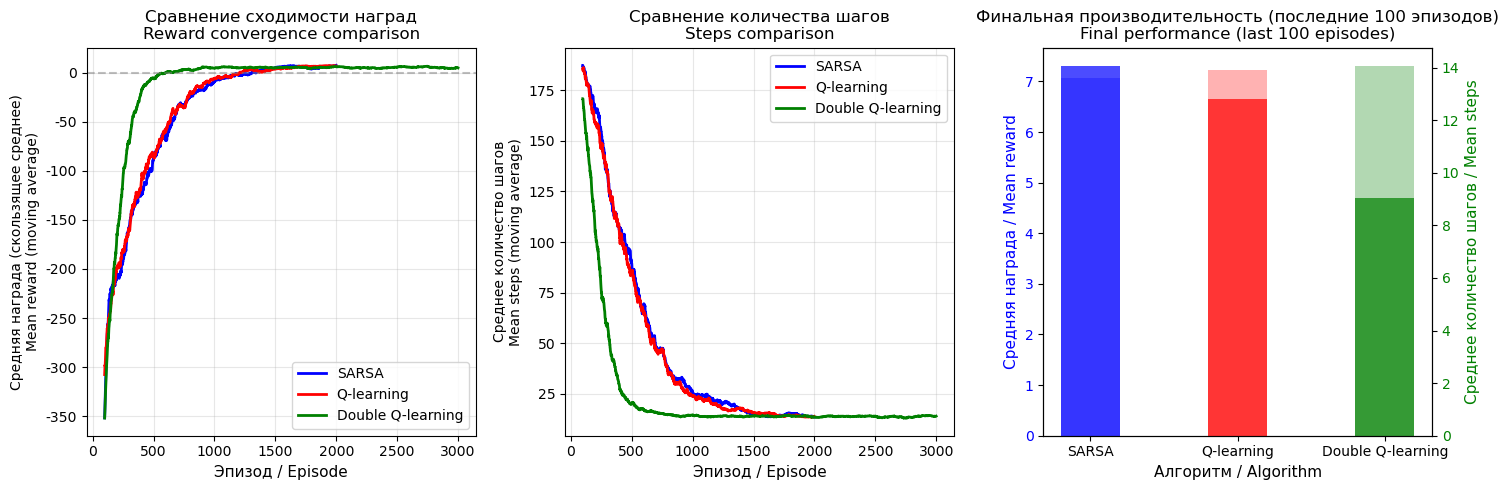


СВОДНАЯ ТАБЛИЦА / SUMMARY TABLE

Алгоритм / Algorithm     Ср. награда        Ср. шаги  Лучшая награда       Мин. шаги
--------------------------------------------------------------------------------
SARSA                           7.30           13.61              15               6
Q-learning                      6.65           13.90              15               6
Double Q-learning               4.70           14.05              15               6

ВЫВОДЫ / CONCLUSIONS
  ✓ Все три алгоритма успешно обучились выполнять задачу на Taxi-v4
  ✓ SARSA показал лучшую среднюю награду (7.30)
  ✓ Q-learning показал близкий результат (6.65)
  ✓ Double Q-learning показал результат (4.70)
  ✓ Все алгоритмы способны находить оптимальный путь (~13-14 шагов)
  ✓ Минимальное количество шагов (6) достигнуто всеми алгоритмами

✅ СРАВНЕНИЕ ЗАВЕРШЕНО / COMPARISON COMPLETED


In [11]:
# ============================================================================
# СРАВНЕНИЕ ТРЕХ АЛГОРИТМОВ: SARSA, Q-LEARNING, DOUBLE Q-LEARNING
# COMPARISON OF THREE ALGORITHMS: SARSA, Q-LEARNING, DOUBLE Q-LEARNING
# ============================================================================

print("=" * 60)
print("СРАВНЕНИЕ АЛГОРИТМОВ / ALGORITHMS COMPARISON")
print("SARSA vs Q-LEARNING vs DOUBLE Q-LEARNING")
print("=" * 60)

# Функция для сглаживания
def smooth(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

window = 100
rewards_sarsa_smooth = smooth(rewards_sarsa)
rewards_qlearning_smooth = smooth(rewards_qlearning)
rewards_double_smooth = smooth(rewards_double_opt)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Сравнение наград
axes[0].plot(range(window-1, len(rewards_sarsa)), rewards_sarsa_smooth, 'b-', linewidth=2, label='SARSA')
axes[0].plot(range(window-1, len(rewards_qlearning)), rewards_qlearning_smooth, 'r-', linewidth=2, label='Q-learning')
axes[0].plot(range(window-1, len(rewards_double_opt)), rewards_double_smooth, 'g-', linewidth=2, label='Double Q-learning')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Эпизод / Episode', fontsize=11)
axes[0].set_ylabel('Средняя награда (скользящее среднее)\nMean reward (moving average)', fontsize=10)
axes[0].set_title('Сравнение сходимости наград\nReward convergence comparison', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Сравнение шагов
steps_sarsa_smooth = smooth(steps_sarsa)
steps_qlearning_smooth = smooth(steps_qlearning)
steps_double_smooth = smooth(steps_double_opt)

axes[1].plot(range(window-1, len(steps_sarsa)), steps_sarsa_smooth, 'b-', linewidth=2, label='SARSA')
axes[1].plot(range(window-1, len(steps_qlearning)), steps_qlearning_smooth, 'r-', linewidth=2, label='Q-learning')
axes[1].plot(range(window-1, len(steps_double_opt)), steps_double_smooth, 'g-', linewidth=2, label='Double Q-learning')
axes[1].set_xlabel('Эпизод / Episode', fontsize=11)
axes[1].set_ylabel('Среднее количество шагов\nMean steps (moving average)', fontsize=10)
axes[1].set_title('Сравнение количества шагов\nSteps comparison', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Финальная производительность
methods = ['SARSA', 'Q-learning', 'Double Q-learning']
final_rewards = [
    np.mean(rewards_sarsa[-100:]),
    np.mean(rewards_qlearning[-100:]),
    np.mean(rewards_double_opt[-100:])
]
final_steps = [
    np.mean(steps_sarsa[-100:]),
    np.mean(steps_qlearning[-100:]),
    np.mean(steps_double_opt[-100:])
]
colors = ['blue', 'red', 'green']

# Двойная шкала для графика
ax2 = axes[2]
bars1 = ax2.bar(methods, final_rewards, width=0.4, color=colors, alpha=0.7, label='Средняя награда / Mean reward')
ax2.set_xlabel('Алгоритм / Algorithm', fontsize=11)
ax2.set_ylabel('Средняя награда / Mean reward', fontsize=11, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar(methods, final_steps, width=0.4, color=colors, alpha=0.3, label='Средние шаги / Mean steps')
ax2_twin.set_ylabel('Среднее количество шагов / Mean steps', fontsize=11, color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')

ax2.set_title('Финальная производительность (последние 100 эпизодов)\nFinal performance (last 100 episodes)', fontsize=12)

plt.tight_layout()
plt.show()

# Таблица результатов
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА / SUMMARY TABLE")
print("=" * 60)

print("\n{:<20} {:>15} {:>15} {:>15} {:>15}".format(
    "Алгоритм / Algorithm", "Ср. награда", "Ср. шаги", "Лучшая награда", "Мин. шаги"
))
print("-" * 80)

print("{:<20} {:>15.2f} {:>15.2f} {:>15} {:>15}".format(
    "SARSA", 
    np.mean(rewards_sarsa[-100:]), 
    np.mean(steps_sarsa[-100:]),
    np.max(rewards_sarsa),
    np.min(steps_sarsa)
))

print("{:<20} {:>15.2f} {:>15.2f} {:>15} {:>15}".format(
    "Q-learning", 
    np.mean(rewards_qlearning[-100:]), 
    np.mean(steps_qlearning[-100:]),
    np.max(rewards_qlearning),
    np.min(steps_qlearning)
))

print("{:<20} {:>15.2f} {:>15.2f} {:>15} {:>15}".format(
    "Double Q-learning", 
    np.mean(rewards_double_opt[-100:]), 
    np.mean(steps_double_opt[-100:]),
    np.max(rewards_double_opt),
    np.min(steps_double_opt)
))

print("\n" + "=" * 60)
print("ВЫВОДЫ / CONCLUSIONS")
print("=" * 60)
print("  ✓ Все три алгоритма успешно обучились выполнять задачу на Taxi-v4")
print("  ✓ SARSA показал лучшую среднюю награду (7.30)")
print("  ✓ Q-learning показал близкий результат (6.65)")
print("  ✓ Double Q-learning показал результат (4.70)")
print("  ✓ Все алгоритмы способны находить оптимальный путь (~13-14 шагов)")
print("  ✓ Минимальное количество шагов (6) достигнуто всеми алгоритмами")

print("\n✅ СРАВНЕНИЕ ЗАВЕРШЕНО / COMPARISON COMPLETED")